# **Traffic Sign Recognition**
# **Made by:** **[Chinmay Shastry]** & **[Sharanya Makam]**

# **Project team's ID:** **PTID-AI-FEB-26-1094**

# **Project Code:** **PRAICP-1002 — Traffic Sign Recognition**


# PRAICP-1002 — Traffic Sign Recognition

**Objective:** Build a CNN-based model to classify German traffic signs from the GTSRB dataset.  


---

## **MOUNT GOOGLE DRIVE AND EXTRACT DATA**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile
import os

zip_file_path = "/content/drive/MyDrive/Internship Projects/AI Projects/Traffic sign detection/PRAICP-1002-TrafSignDetc.zip"
extraction_path = "/content/traffic_sign_data"

# Create directory
os.makedirs(extraction_path, exist_ok=True)

# Extract dataset
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print("✅ Dataset extracted successfully!")

# Check files
print("\nDataset contents:")
!ls -R {extraction_path} | head -50

✅ Dataset extracted successfully!

Dataset contents:
/content/traffic_sign_data:
meta
Meta
Meta.csv
test
Test
Test.csv
train
Train
Train.csv

/content/traffic_sign_data/meta:
0.png
10.png
11.png
12.png
13.png
14.png
15.png
16.png
17.png
18.png
19.png
1.png
20.png
21.png
22.png
23.png
24.png
25.png
26.png
27.png
28.png
29.png
2.png
30.png
31.png
32.png
33.png
34.png
35.png
36.png
37.png
38.png
39.png
3.png
40.png
41.png
42.png
4.png


## **IMPORTING NECESSARY LIBRARIES AND DEFINING CONSTANTS**

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Constants ──────────────────────────────────────────────────────────────────
IMG_SIZE    = 32          # Resize all images to 32×32
NUM_CLASSES = 43          # GTSRB has exactly 43 classes (0–42)
BATCH_SIZE  = 64
EPOCHS      = 20

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.19.0


---
## Data Loading & Exploration

Load `Train.csv` and `Test.csv`, inspect their structure, check for missing values, and review the class distribution.

In [4]:
train_df =  pd.read_csv("/content/traffic_sign_data/Train.csv")
test_df  = pd.read_csv("/content/traffic_sign_data/Test.csv")

print("=== Train DataFrame — first 5 rows ===")
display(train_df.head())

print("\n=== Test DataFrame — first 5 rows ===")
display(test_df.head())

print("\n=== Train DataFrame Info ===")
train_df.info()

print("\n=== Test DataFrame Info ===")
test_df.info()

print(f"\nUnique classes in Train set : {train_df['ClassId'].nunique()}")
print(f"Missing values in Train     : {train_df.isnull().sum().sum()}")
print(f"Missing values in Test      : {test_df.isnull().sum().sum()}")

=== Train DataFrame — first 5 rows ===


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png



=== Test DataFrame — first 5 rows ===


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png



=== Train DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB

=== Test DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12630 entries, 0 to 12629
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    12630 non-null  int64 
 1   Height   12630 non-null  int64 
 2   Roi.X1   12630 non-null  int64 
 3   Roi.Y1   12630 non-null  int64 
 4   Roi.X2   12630 non-null  int64 
 5   Roi.Y2   12630 non-null  int64 
 6   Clas

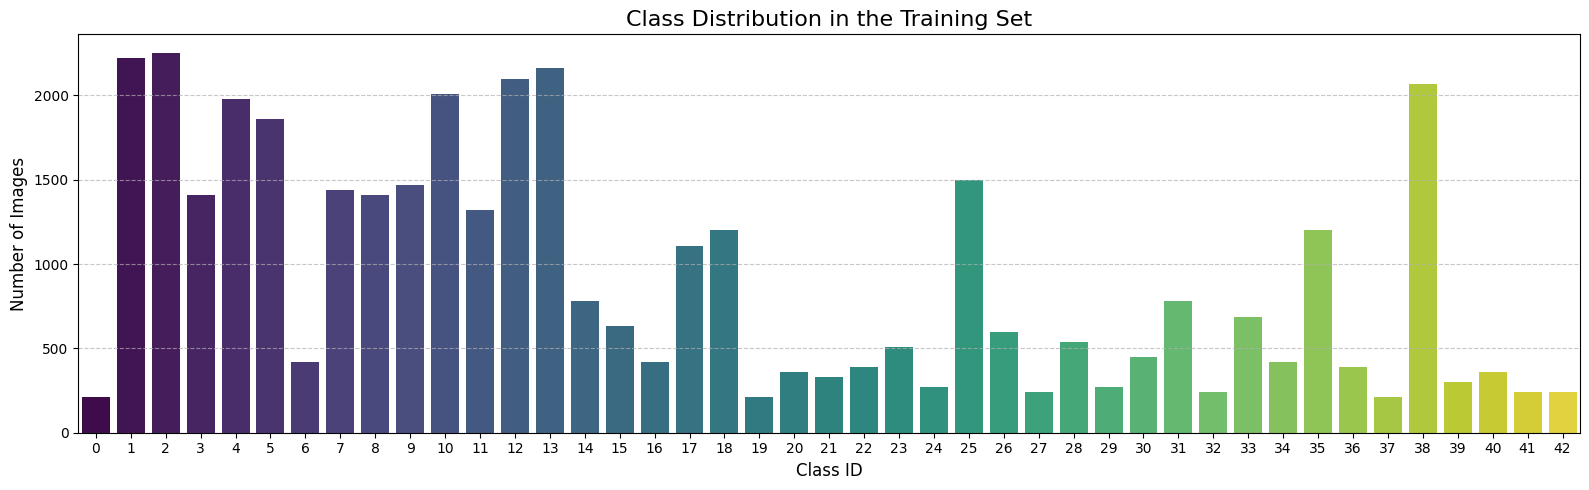

In [5]:
plt.figure(figsize=(16, 5))

# hue=ClassId avoids the Seaborn FutureWarning; legend=False removes the redundant legend
sns.countplot(
    x='ClassId',
    data=train_df,
    hue='ClassId',
    palette='viridis',
    legend=False
)

plt.title('Class Distribution in the Training Set', fontsize=16)
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **SAMPLE IMAGE OF EACH CLASS**

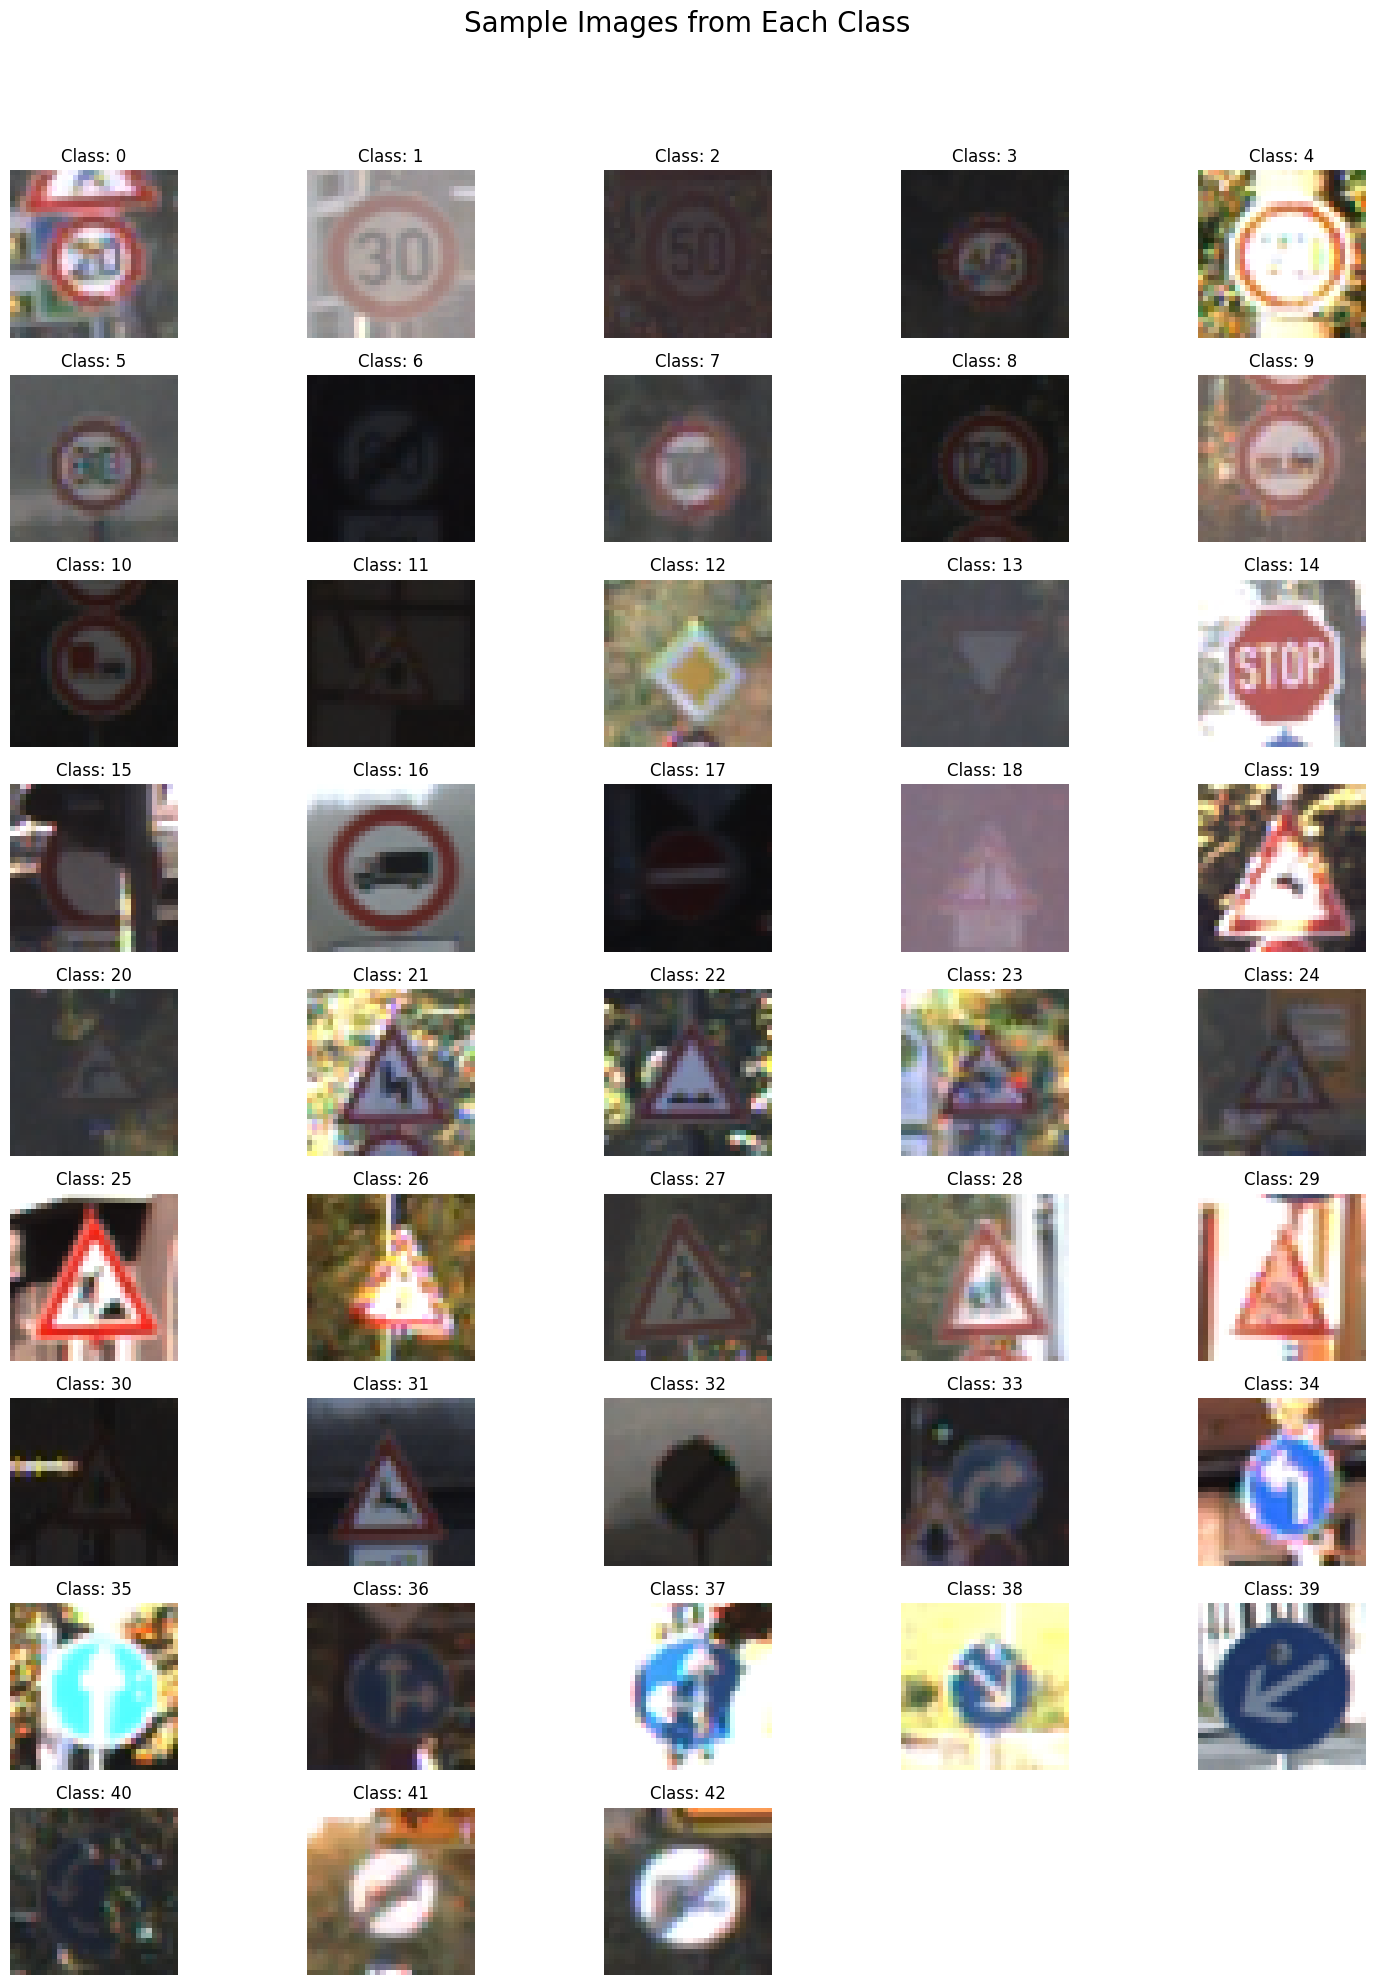

In [27]:
unique_classes = sorted(train_df['ClassId'].unique())

plt.figure(figsize=(15, 20))

for i, class_id in enumerate(unique_classes):
    # Get the first image path for the current class_id
    sample_path = train_df[train_df['ClassId'] == class_id].iloc[0]['Path']
    full_sample_path = os.path.join(extraction_path, sample_path)

    # Load and display the image
    img = Image.open(full_sample_path).resize((IMG_SIZE, IMG_SIZE))

    plt.subplot(9, 5, i + 1) # Arrange in a grid, e.g., 9 rows, 5 columns
    plt.imshow(img)
    plt.title(f"Class: {class_id}")
    plt.axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

---
## Image Preprocessing

- Resize every image to **32 × 32** pixels  
- Normalise pixel values to **[0, 1]**  
- One-hot encode class labels (43 classes)  
- Stratified **80 / 20** train / validation split

In [6]:
def load_and_preprocess_images(df, base_path):
    """Load images from paths in a DataFrame, resize, and normalise."""
    data, labels = [], []

    for _, row in df.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        try:
            img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            data.append(np.array(img))
            labels.append(row['ClassId'])
        except Exception as e:
            print(f"[WARNING] Could not load {img_path}: {e}")

    X = np.array(data, dtype='float32') / 255.0
    y = np.array(labels, dtype='int32')
    return X, y


print("Loading training images...")
X_train_full, y_train_full = load_and_preprocess_images(train_df, base_path=extraction_path)

print("Loading test images...")
X_test, y_test_raw = load_and_preprocess_images(test_df, base_path=extraction_path)

# One-hot encode — NUM_CLASSES is fixed to 43 to guarantee a consistent shape
# regardless of which classes appear in the loaded subset
y_train_full_ohe = to_categorical(y_train_full, num_classes=NUM_CLASSES)
y_test_ohe       = to_categorical(y_test_raw,   num_classes=NUM_CLASSES)

# Stratified 80/20 train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_ohe,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full   # stratify on integer labels, not one-hot vectors
)

print(f"\nX_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}  |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}  |  y_test  : {y_test_ohe.shape}")

Loading training images...
Loading test images...

X_train : (31367, 32, 32, 3)  |  y_train : (31367, 43)
X_val   : (7842, 32, 32, 3)  |  y_val   : (7842, 43)
X_test  : (12630, 32, 32, 3)  |  y_test  : (12630, 43)


---
## CNN Architecture

Two convolutional blocks followed by a fully-connected head:

| Block | Layers |
|-------|--------|
| Block 1 | Conv2D(32, 5×5) → Conv2D(32, 5×5) → MaxPool(2×2) → Dropout(0.25) |
| Block 2 | Conv2D(64, 3×3) → Conv2D(64, 3×3) → MaxPool(2×2) → Dropout(0.25) |
| Head | Flatten → Dense(256) → Dropout(0.5) → Dense(43, softmax) |

In [7]:
model = Sequential([
    # Using an explicit Input layer avoids the Keras 3 UserWarning
    # that occurs when input_shape is passed directly to the first Conv2D
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # ── Block 1 ────────────────────────────────────────────────────────────────
    Conv2D(32, (5, 5), activation='relu'),
    Conv2D(32, (5, 5), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # ── Block 2 ────────────────────────────────────────────────────────────────
    Conv2D(64, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # ── Fully Connected Head ───────────────────────────────────────────────────
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,939 (1.36 MB)

 Trainable params: 356,939 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

---
## Model Training

Train for up to **20 epochs** with:
- `EarlyStopping` — stops if `val_loss` does not improve for 5 consecutive epochs  
- `ReduceLROnPlateau` — halves the learning rate after 3 stagnant epochs

In [8]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"Training for up to {EPOCHS} epochs | batch size = {BATCH_SIZE}")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

print("\nTraining complete.")

Training for up to 20 epochs | batch size = 64
Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5752 - loss: 1.5287 - val_accuracy: 0.9550 - val_loss: 0.1819 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9265 - loss: 0.2422 - val_accuracy: 0.9852 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9569 - loss: 0.1405 - val_accuracy: 0.9897 - val_loss: 0.0476 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9708 - loss: 0.0968 - val_accuracy: 0.9930 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9757 - loss: 0.0804 - val_accuracy: 0.9936 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9810 - loss: 0.0601 - val_accuracy: 0.9941 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━

---
## Model Evaluation

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

Test Loss     : 0.1109
Test Accuracy : 97.97%


---
## Training Curves

Visualise accuracy and loss over epochs to check for overfitting.

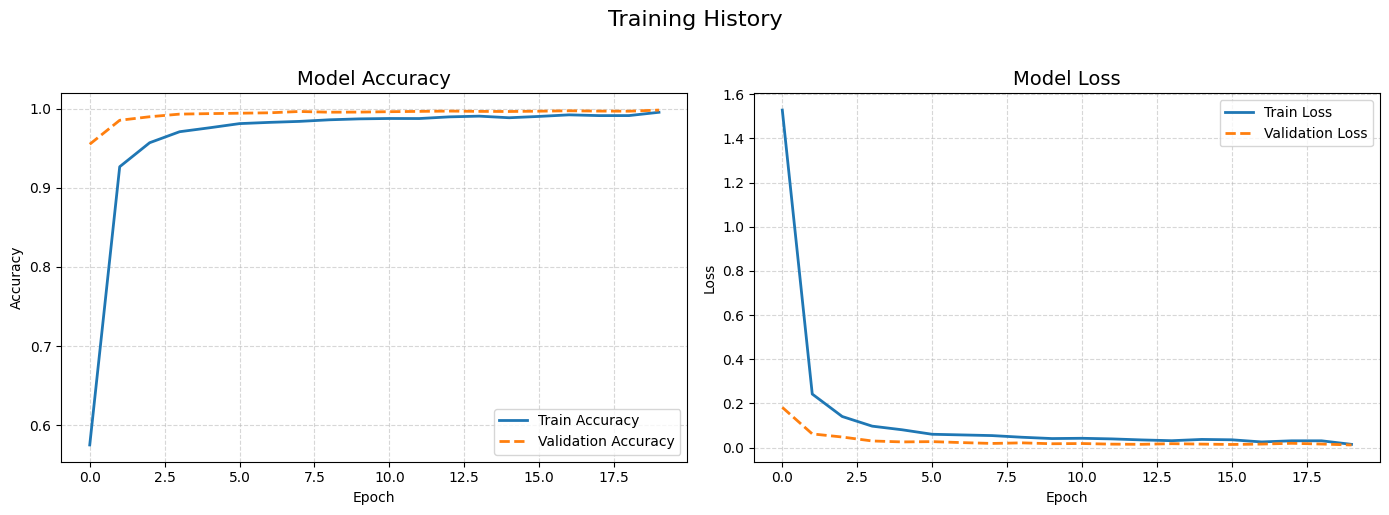

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ───────────────────────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# ── Loss ───────────────────────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],     label='Train Loss',      linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Training History', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## Single Image Prediction

Pick a random image from the test set and verify the model's prediction.

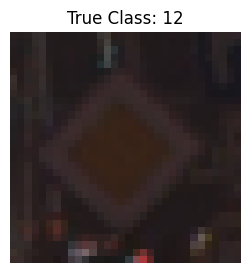

True Class      : 12
Predicted Class : 12
Confidence      : 100.00%
✅  Correct prediction!


In [15]:
idx          = random.randint(0, len(X_test) - 1)
sample_image = X_test[idx]
true_label   = y_test_raw[idx]   # integer label from the raw (non-OHE) array

# Display the image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.axis('off')
plt.title(f"True Class: {true_label}", fontsize=12)
plt.show()

# Predict — model.predict expects a batch, so expand dims from (32,32,3) → (1,32,32,3)
pred_probs      = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)
predicted_class = int(np.argmax(pred_probs))
confidence      = float(np.max(pred_probs))

print(f"True Class      : {true_label}")
print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence * 100:.2f}%")

if predicted_class == true_label:
    print("✅  Correct prediction!")
else:
    print("❌  Incorrect prediction.")

---
## Error Analysis: Identify Misclassified Images

In [16]:
print("Generating predictions for the full test set...")
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)   # predicted integer labels
y_true       = y_test_raw                         # true integer labels (already 1-D)

misclassified_indices = np.where(y_pred != y_true)[0]

total_errors  = len(misclassified_indices)
total_samples = len(X_test)
error_rate    = (total_errors / total_samples) * 100

print(f"Total test samples       : {total_samples}")
print(f"Misclassified images     : {total_errors}")
print(f"Overall error rate       : {error_rate:.2f}%")
print(f"\nFirst 10 misclassified indices: {misclassified_indices[:10]}")

Generating predictions for the full test set...
Total test samples       : 12630
Misclassified images     : 256
Overall error rate       : 2.03%

First 10 misclassified indices: [ 50 114 127 147 198 237 287 374 421 459]


---
## Confusion Matrix



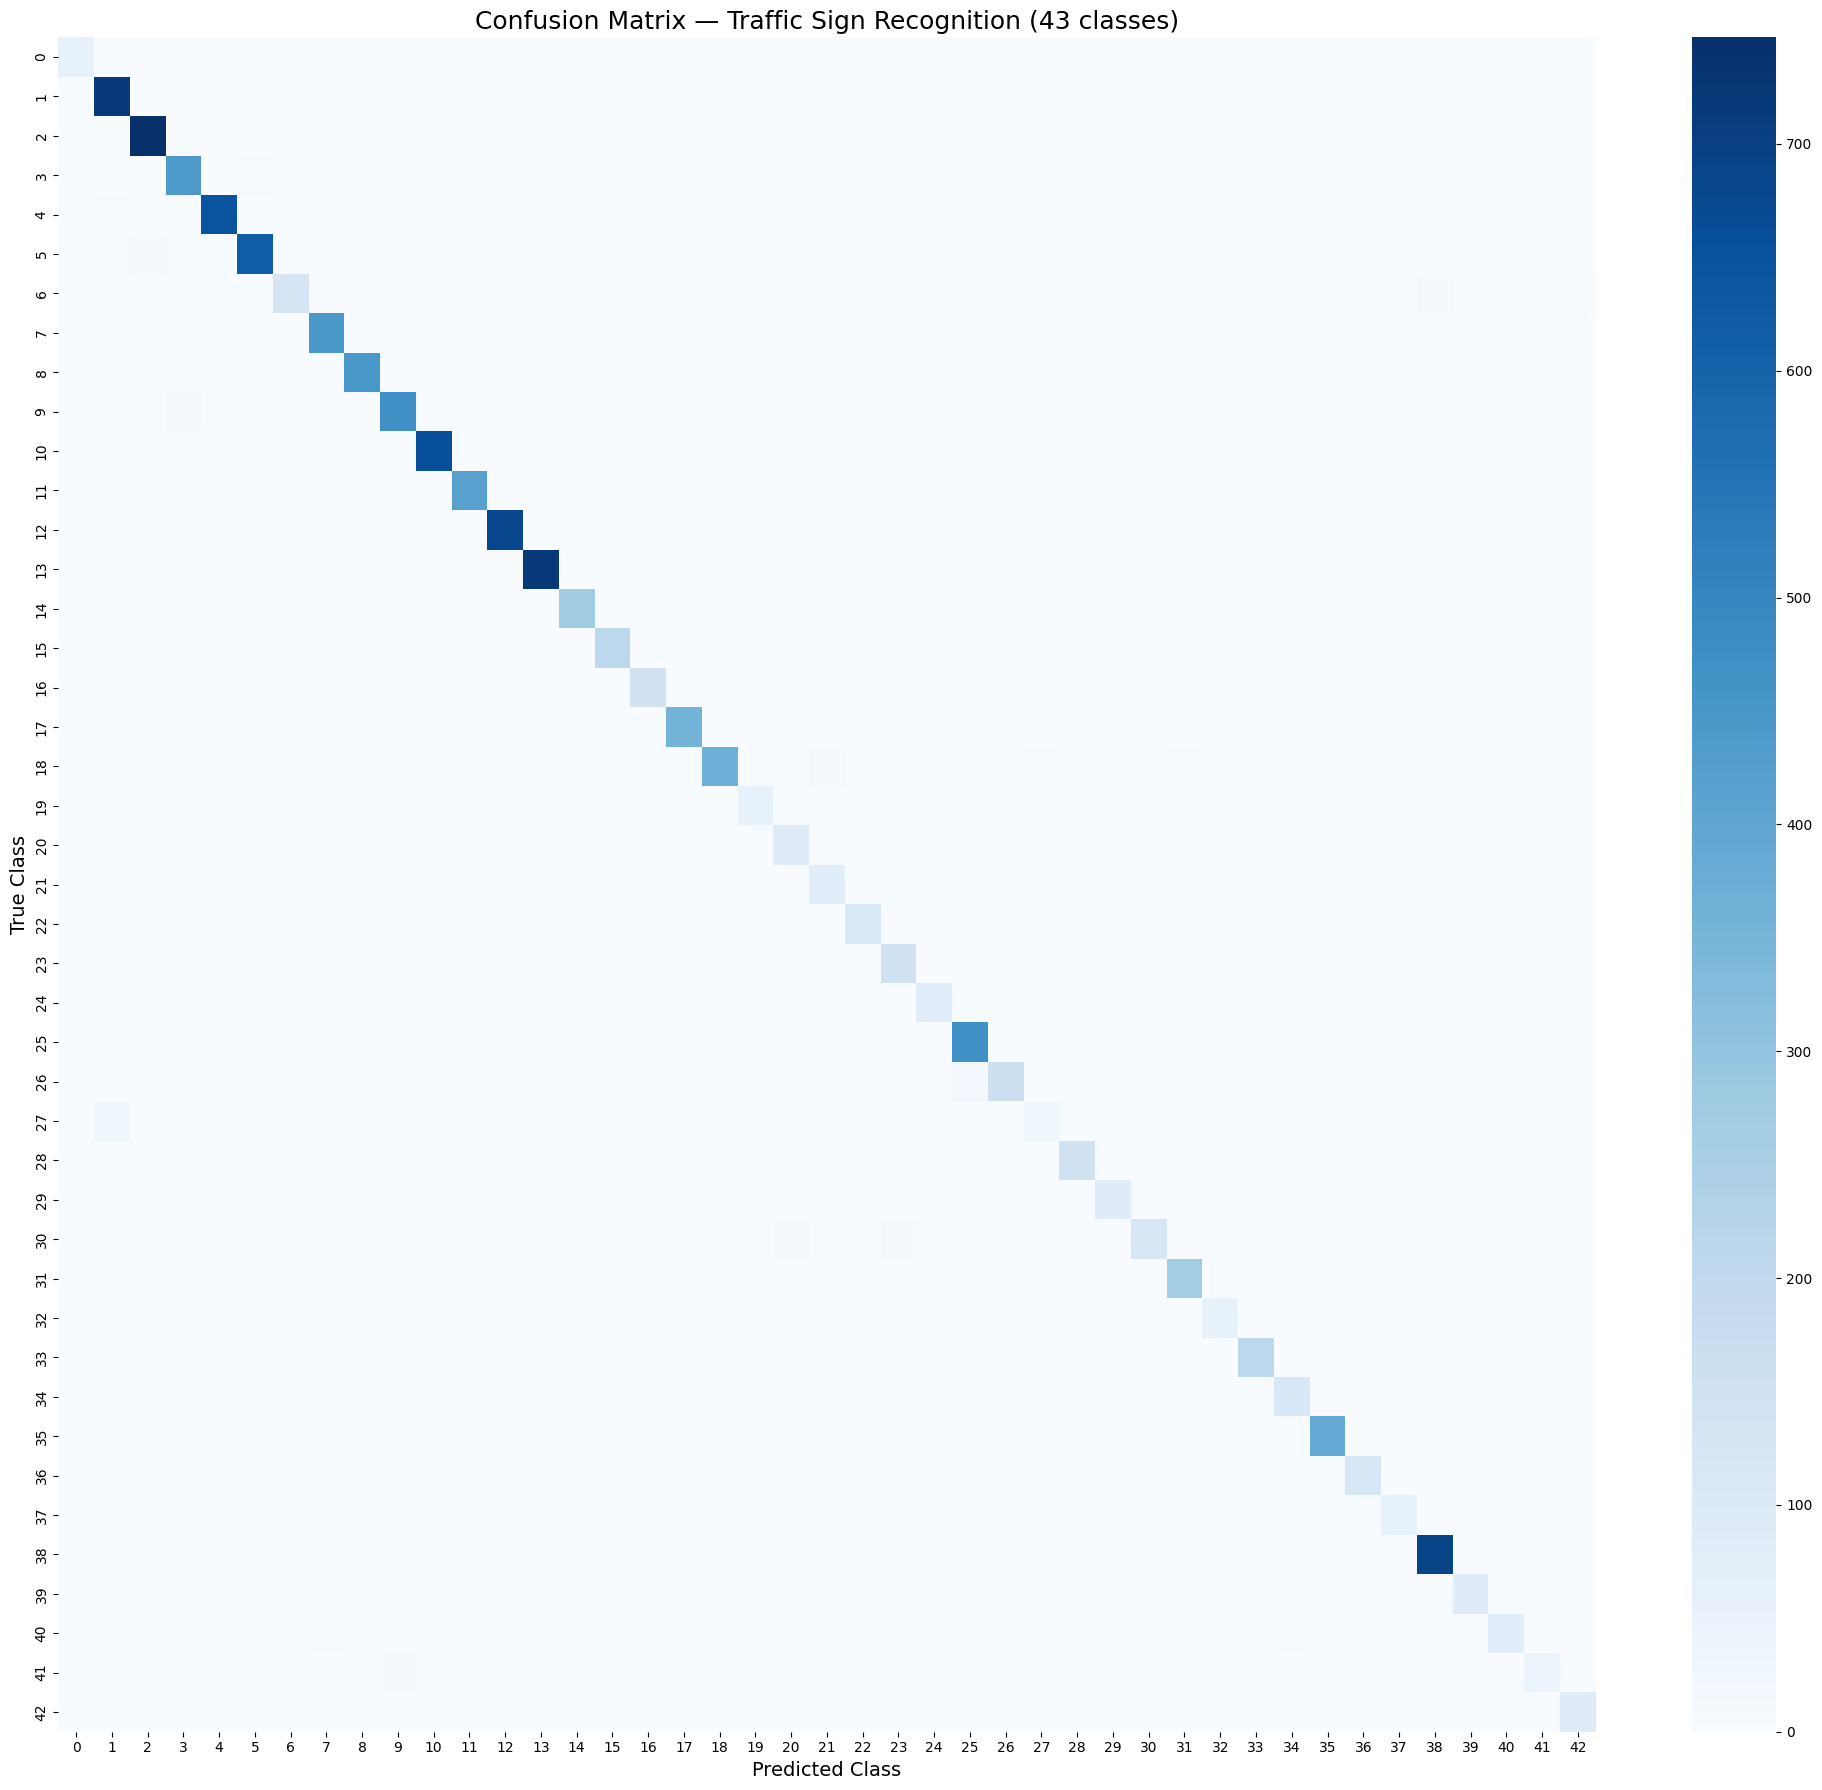

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES)
)
plt.title('Confusion Matrix — Traffic Sign Recognition (43 classes)', fontsize=18)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)
plt.tight_layout()
plt.show()

## **CLASSIFICATION REPORT**

In [36]:
from sklearn.metrics import classification_report

# y_true and y_pred are already available from previous cells
print("Classification Report:")
print(classification_report(y_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.94      0.99      0.97       720
           2       0.98      1.00      0.99       750
           3       0.97      0.98      0.98       450
           4       1.00      0.98      0.99       660
           5       0.99      0.97      0.98       630
           6       1.00      0.86      0.92       150
           7       0.99      0.99      0.99       450
           8       0.99      1.00      0.99       450
           9       0.97      0.98      0.97       480
          10       1.00      1.00      1.00       660
          11       0.99      0.99      0.99       420
          12       1.00      0.99      0.99       690
          13       0.99      1.00      0.99       720
          14       1.00      1.00      1.00       270
          15       0.97      1.00      0.98       210
          16       1.00      0.99      1.00       150
    

## Analysis Report: Traffic Sign Recognition using CNN

### 1. Project Objective
This project aimed to build a Convolutional Neural Network (CNN) model for classifying German traffic signs using the German Traffic Sign Recognition Benchmark (GTSRB) dataset. The goal was to achieve high accuracy in identifying different traffic signs, which is crucial for autonomous driving and advanced driver-assistance systems.

### 2. Dataset Overview
The GTSRB dataset consists of images of 43 distinct traffic sign classes. The dataset was loaded from `Train.csv` and `Test.csv`, revealing:
- **Training Set**: 39,209 images.
- **Test Set**: 12,630 images.
- **Image Properties**: Images varied in size but were preprocessed to 32x32 pixels.
- **Class Distribution**: The training set exhibited an imbalanced class distribution, with some classes having significantly more samples than others. This is a common characteristic of real-world datasets.

### 3. Image Preprocessing
- **Resizing**: All images were resized to 32x32 pixels to maintain consistency and reduce computational load.
- **Normalization**: Pixel values were scaled to the [0, 1] range by dividing by 255.0.
- **One-Hot Encoding**: Class labels were converted into one-hot encoded vectors, suitable for categorical cross-entropy loss.
- **Train/Validation Split**: The training data was split into an 80/20 train/validation set using a stratified sampling approach to ensure representative class distribution in both splits.

### 4. Model Architecture
The CNN model used a sequential architecture comprising two convolutional blocks followed by a fully-connected head:
- **Block 1**: `Conv2D(32, 5x5)` → `Conv2D(32, 5x5)` → `MaxPooling2D(2x2)` → `Dropout(0.25)`
- **Block 2**: `Conv2D(64, 3x3)` → `Conv2D(64, 3x3)` → `MaxPooling2D(2x2)` → `Dropout(0.25)`
- **Head**: `Flatten` → `Dense(256, relu)` → `Dropout(0.5)` → `Dense(43, softmax)`

The model was compiled with the `adam` optimizer, `categorical_crossentropy` loss, and `accuracy` as the evaluation metric.

### 5. Training Process
The model was trained for up to 20 epochs with a batch size of 64. To prevent overfitting and optimize learning, the following callbacks were used:
- **EarlyStopping**: Monitored `val_loss` with a patience of 5 epochs, restoring the best weights.
- **ReduceLROnPlateau**: Reduced the learning rate by a factor of 0.5 if `val_loss` did not improve for 3 consecutive epochs, with a minimum learning rate of 1e-6.

### 6. Model Performance
After training, the model demonstrated strong performance on the unseen test set:
- **Test Loss**: Approximately `0.1109`
- **Test Accuracy**: Approximately `97.97%`
- **Misclassified Images**: Around 256 out of 12,630 test samples, resulting in an overall error rate of approximately 2.03%.

These results indicate that the CNN model effectively learned to classify the various traffic signs with high precision.

---

## **INTERACTIVE DASHBOARD**

In [41]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# --- Sample Metrics (replace with your real values) ----
test_accuracy = 97.97
error_rate = 2.03

# --- KPI Cards ---
fig_kpi = go.Figure()

fig_kpi.add_trace(go.Indicator(
    mode = "number",
    value = test_accuracy,
    title = {"text": "<span style='font-size:1.2em; color:rgb(0,204,150)'>Test Accuracy (%)</span>"},
    number = {'font_color': "rgb(0,204,150)"},
    domain = {'x': [0, 0.5], 'y': [0, 1]}
))

fig_kpi.add_trace(go.Indicator(
    mode = "number",
    value = error_rate,
    title = {"text": "<span style='font-size:1.2em; color:rgb(255,65,54)'>Error Rate (%)</span>"},
    number = {'font_color': "rgb(255,65,54)"},
    domain = {'x': [0.5, 1], 'y': [0, 1]}
))

fig_kpi.update_layout(
    height=200,
    margin=dict(l=20, r=20, t=50, b=20),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)"
)
fig_kpi.show()


# --- Class Distribution ---
class_counts = train_df['ClassId'].value_counts().sort_index()

fig_dist = px.bar(
    x=class_counts.index,
    y=class_counts.values,
    labels={'x': 'Class ID', 'y': 'Count'},
    title="Class Distribution in Training Set",
    color=class_counts.values, # Color based on count
    color_continuous_scale=px.colors.sequential.Viridis, # Use a sequential color scale
    template="plotly_dark" # Use a dark theme
)

fig_dist.update_layout(
    title_font_size=18,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)"
)
fig_dist.show()


# --- Confusion Matrix ---
fig_cm = px.imshow(
    cm,
    labels=dict(x="Predicted Class", y="True Class", color="Count"),
    title="Confusion Matrix — Traffic Sign Recognition (43 classes)",
    color_continuous_scale="Hot", # Use a 'Hot' color scale for the heatmap
    aspect="auto", # Adjust aspect ratio automatically
    template="plotly_dark" # Use a dark theme
)

fig_cm.update_layout(
    title_font_size=18,
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    xaxis_showgrid=False, # Remove gridlines for a cleaner look
    yaxis_showgrid=False,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)"
)
fig_cm.show()


# --- Interactive Class Explorer ---
def show_class_performance(class_id):
    total = np.sum(y_true == class_id)
    correct = np.sum((y_true == class_id) & (y_pred == class_id))

    acc = (correct / total) * 100 if total > 0 else 0

    print(f"\nClass {class_id}")
    print(f"Total Samples: {total}")
    print(f"Correct Predictions: {correct}")
    print(f"Accuracy: {acc:.2f}%")

dropdown = widgets.Dropdown(
    options=sorted(np.unique(y_true)),
    description='Class ID:',
)

widgets.interact(show_class_performance, class_id=dropdown)


interactive(children=(Dropdown(description='Class ID:', options=(np.int32(0), np.int32(1), np.int32(2), np.int…

<function __main__.show_class_performance(class_id)>

## Challenges and Improvements

### Key Observations (Challenges Faced)
1.  **Strong Overall Accuracy**: The model achieved high accuracy, with a dominant diagonal in the confusion matrix, indicating successful classification for most signs.
2.  **Speed Limit Confusion**: The most common misclassifications occurred among similar speed limit signs (e.g., Class 1 / 2 / 3 / 4 — 30, 50, 60, 70 km/h). These signs share identical circular shapes, differing only by the inner numeral, which becomes challenging to distinguish at a low resolution of 32x32 pixels.
3.  **Warning Sign Confusion**: Certain triangular warning signs (e.g., Classes 23, 24, 25, 26) also showed cross-class confusion due to their similar silhouettes.
4.  **Qualitative Error Causes**: Visual inspection of misclassified images revealed common culprits such as motion blur, low contrast, partial occlusion, and very small objects within the bounding box, making accurate recognition difficult.
5. **Transfer Learning Limitation (Resource Constraint)**: While attempting to implement transfer learning using pre-trained models (such as EfficientNet or ResNet), the notebook environment encountered memory limitations and crashed due to excessive RAM usage. This highlighted the computational constraints of the working environment and limited experimentation with more complex architectures.

### Recommended Next Steps (Improvements)
1.  **Targeted Augmentation**: Implement data augmentation techniques that specifically simulate the identified failure conditions, such as motion blur, brightness jitter, and perspective transforms, to make the model more robust.
2.  **Class-Specific Oversampling**: Address the class imbalance by oversampling the underrepresented classes, especially those prone to confusion (e.g., speed limit and warning signs), to provide the model with more diverse examples.
3.  **Higher Resolution Input**: Experiment with training the model using higher-resolution images (e.g., 48x48 or 64x64 pixels). This would help preserve crucial details, particularly the numerals on speed limit signs, thereby improving their distinguishability.
4.  **Transfer Learning**: Explore fine-tuning a pre-trained convolutional neural network backbone (e.g., EfficientNet-B0, ResNet) on the GTSRB dataset. Transfer learning can significantly boost accuracy, especially with limited data, by leveraging features learned from large, diverse datasets.